##  Diabetes Prediction Project

## Import Libraries

In [40]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading

In this step, the dataset is loaded and basic information about the data is explored, including shape, data types, and summary statistics.

In [41]:
#laddar dataset 
df = pd.read_csv("diabetes.csv")
print(df.shape)
#första rad
df.head()
df.info()
df.describe()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data Exploration 
Exploring dataset structure, distributions, and target variable.

Outcome
0    500
1    268
Name: count, dtype: int64


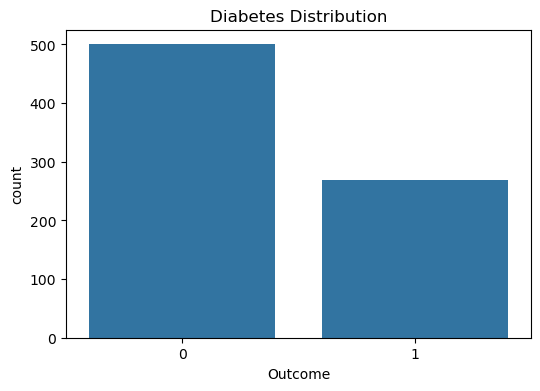

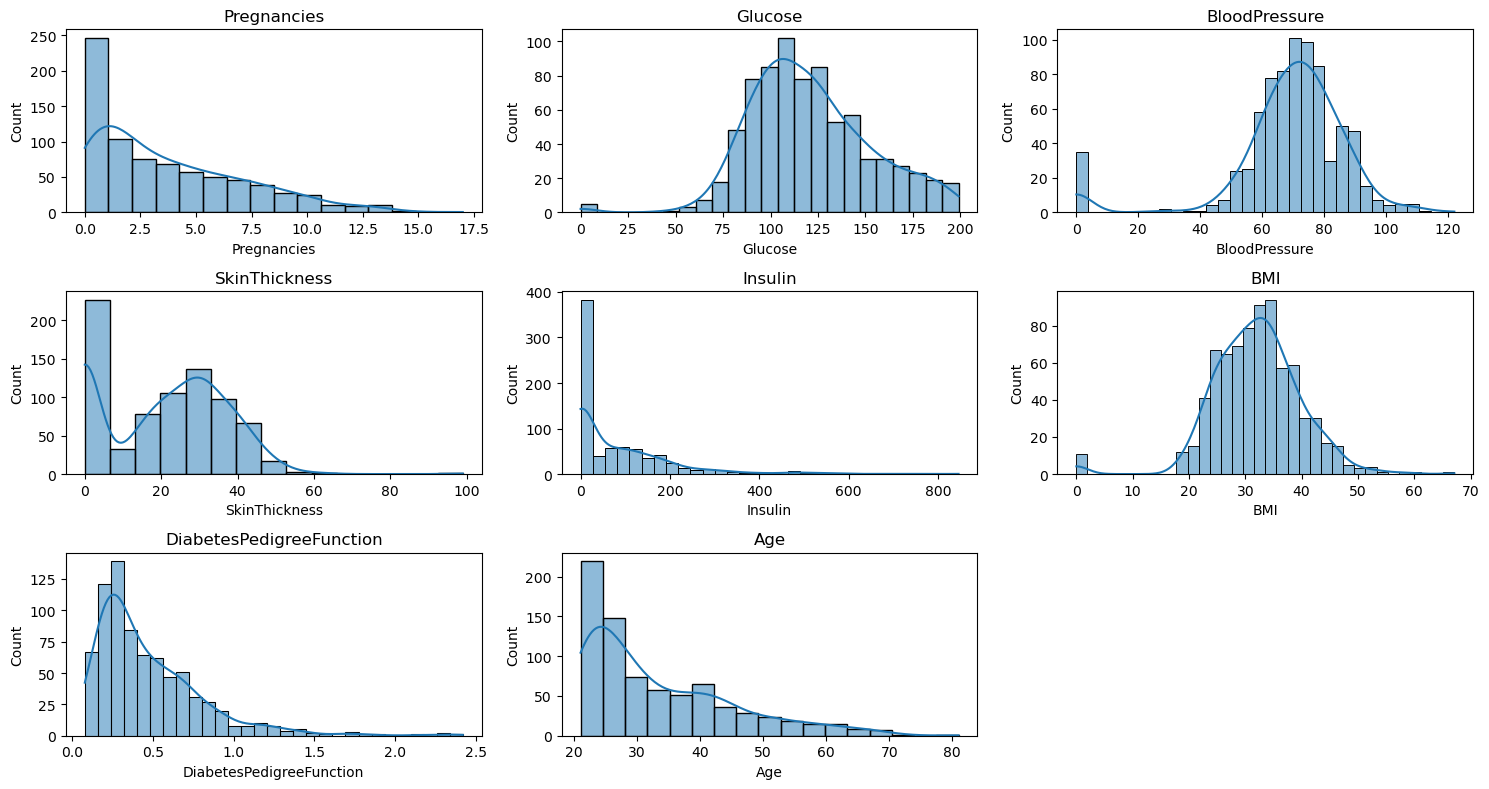

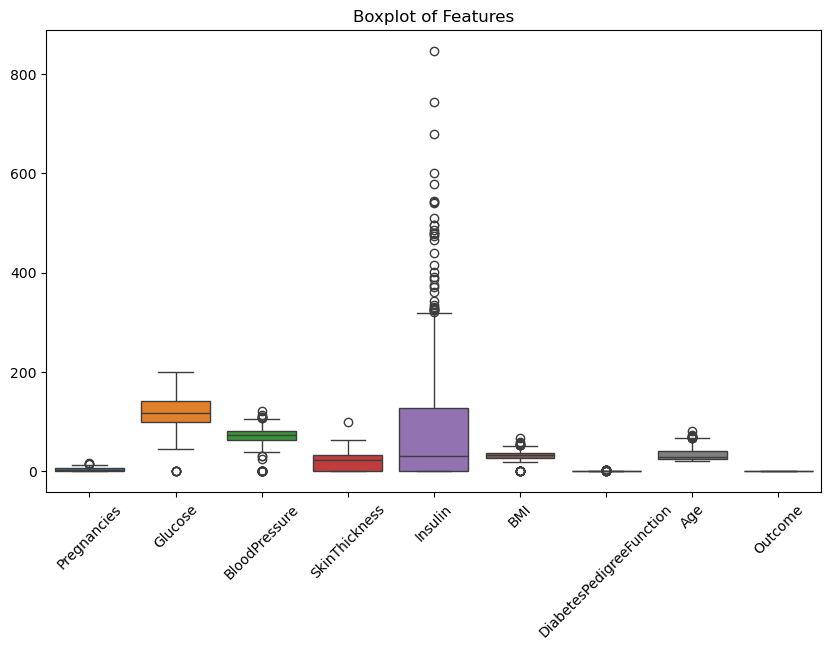

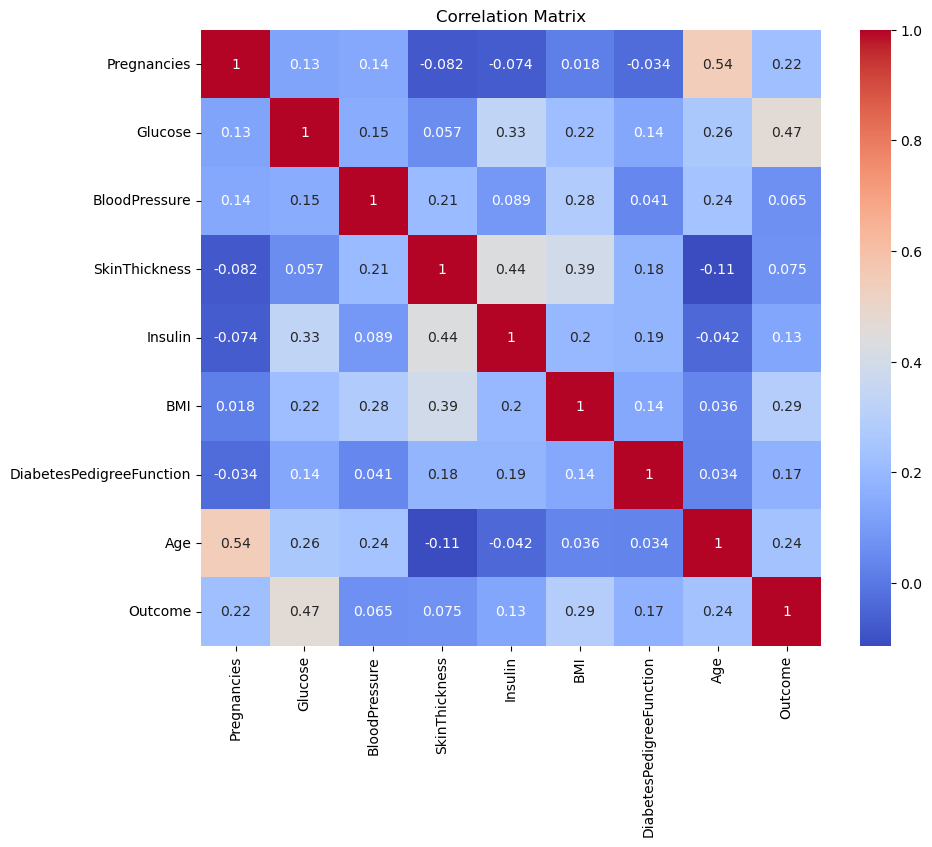

In [42]:
# Distribution of target variable
print(df['Outcome'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Distribution')
plt.show()

# Distribution of numerical features
cols = ['Pregnancies', 'Glucose', 'BloodPressure',
        'SkinThickness', 'Insulin', 'BMI',
        'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Boxplot of Features')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 3. Outlier Detection 
In this step, we detect and remove outliers using the IQR method.

Outlier Pregnancies
IQR: 5.0
Lower Limit: -6.5
Upper Limit: 13.5
-----------------------------
Outlier Glucose
IQR: 41.25
Lower Limit: 37.125
Upper Limit: 202.125
-----------------------------
Outlier BloodPressure
IQR: 18.0
Lower Limit: 35.0
Upper Limit: 107.0
-----------------------------
Outlier SkinThickness
IQR: 32.0
Lower Limit: -48.0
Upper Limit: 80.0
-----------------------------
Outlier Insulin
IQR: 127.25
Lower Limit: -190.875
Upper Limit: 318.125
-----------------------------
Outlier BMI
IQR: 9.3
Lower Limit: 13.35
Upper Limit: 50.550000000000004
-----------------------------
Outlier DiabetesPedigreeFunction
IQR: 0.38249999999999995
Lower Limit: -0.32999999999999996
Upper Limit: 1.2
-----------------------------
Outlier Age
IQR: 17.0
Lower Limit: -1.5
Upper Limit: 66.5
-----------------------------
Percentage Outlier:
New shape: (639, 9)


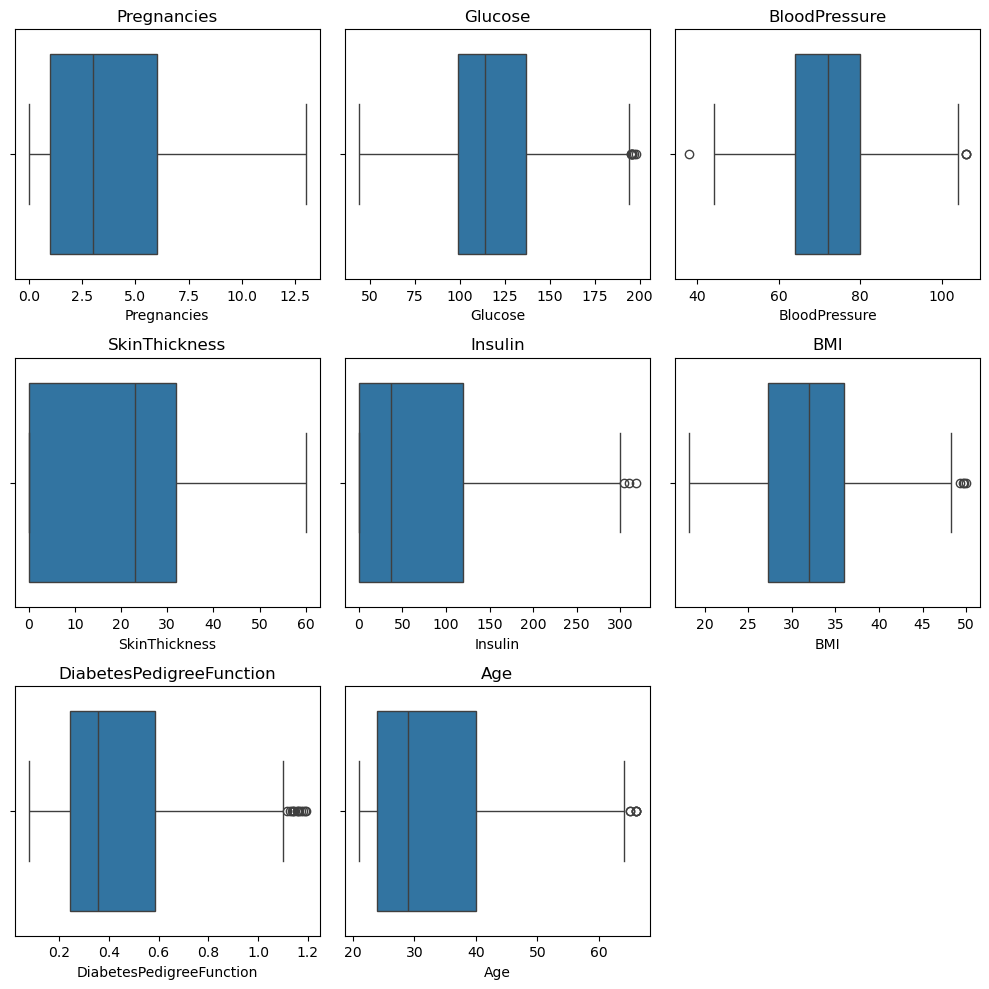

In [43]:
#skapa kopia av dataset 
df_eda = df.copy()
# definiera de numeriska kolumner 
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure',
                  'SkinThickness', 'Insulin', 'BMI',
                  'DiabetesPedigreeFunction', 'Age']


def find_outlier(df, feature):
    print('Outlier', feature)

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1
    limit = iqr * 1.5

    lower_limit = q1 - limit
    upper_limit = q3 + limit

    print(f'IQR: {iqr}')
    print(f'Lower Limit: {lower_limit}')
    print(f'Upper Limit: {upper_limit}')
    print('-----------------------------')

for col in numerical_cols:
    find_outlier(df_eda, col)

outliers_index = []

for col in numerical_cols:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_eda[(df_eda[col] < lower) | (df_eda[col] > upper)].index
    outliers_index.extend(outliers)

outliers_index = list(set(outliers_index))

#Percentage outlier
print("Percentage Outlier:")
len(outliers_index) / len(df_eda) * 100

# Ta bort outliers
df = df_eda.drop(index=outliers_index)
print("New shape:", df.shape)

plt.figure(figsize=(10,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()

## 4. Data Cleaning (Handling Missing Values)

In [44]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 5. Feature Engineering
In this step, we create new features based on existing variables such as BMI and Insulin.

In [45]:
#BMI Group
df['BMI_Group'] = pd.cut(df['BMI'],
                        bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9, 100],
                        labels=['Underweight', 'Normal', 'Overweight',
                                'Obesity 1', 'Obesity 2', 'Obesity 3'])
#Insulin status
df['Insulin_Status'] = pd.cut(df['Insulin'],
                             bins=[0, 100, 200, 300, 1000],
                             labels=['Low', 'Normal', 'High', 'Very High'])
#kontrollera resultat
df[['BMI', 'BMI_Group', 'Insulin', 'Insulin_Status']].head()

,BMI,BMI_Group,Insulin,Insulin_Status
0,33.6,Obesity 1,115.5,Normal
1,26.6,Overweight,115.5,Normal
2,23.3,Normal,115.5,Normal
3,28.1,Overweight,94.0,Low
5,25.6,Overweight,115.5,Normal


# Encoding

In [46]:
df = pd.get_dummies(df, drop_first=True)

## 6. Data Preprocessing
Splitting data and scaling features.

In [47]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Modeling
Training machine learning models.

In [48]:
# Initialize models
log_model = LogisticRegression()
knn_model = KNeighborsClassifier()
rf_model = RandomForestClassifier()

# Train models
log_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8. Model Evaluation
Evaluating model performance.

In [49]:
# The models are evaluated using multiple performance metrics

# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))
    print()

# Evaluate all models
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Random Forest", y_test, y_pred_rf)

# Compare models in one table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

results


--- Logistic Regression ---
Accuracy: 0.8046875
Precision: 0.7391304347826086
Recall: 0.4722222222222222
F1 Score: 0.576271186440678
ROC AUC: 0.7035024154589373

--- KNN ---
Accuracy: 0.7578125
Precision: 0.5862068965517241
Recall: 0.4722222222222222
F1 Score: 0.5230769230769231
ROC AUC: 0.6708937198067634

--- Random Forest ---
Accuracy: 0.828125
Precision: 0.7333333333333333
Recall: 0.6111111111111112
F1 Score: 0.6666666666666666
ROC AUC: 0.7620772946859904



,Model,Accuracy,F1 Score
0,Logistic Regression,0.804688,0.576271
1,KNN,0.757812,0.523077
2,Random Forest,0.828125,0.666667


In [50]:
best_model = results.sort_values(by='Accuracy', ascending=False).iloc[0]
print("Best Model:", best_model['Model'])

Best Model: Random Forest


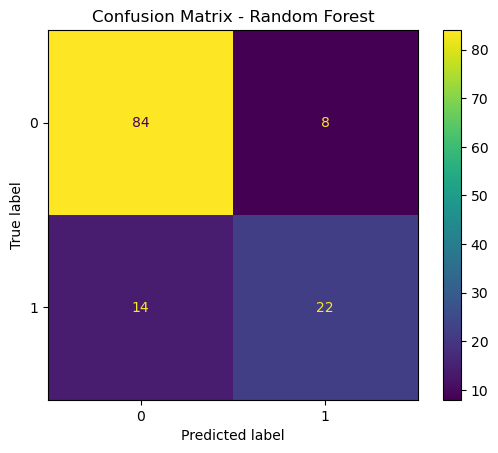

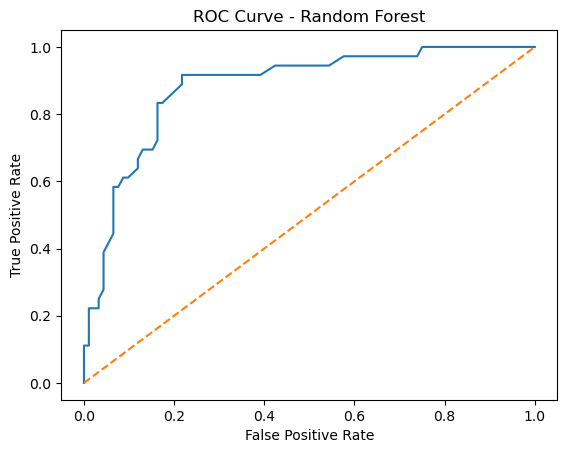

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Random Forest (best model usually)
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

from sklearn.metrics import roc_curve

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()